<a href="https://colab.research.google.com/github/ilariaciampone/progetto-esame/blob/main/Informatica_Beni_Culturali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Humanities e Data Management / Informatica per i Beni Culturali (2025/2026)
# Analisi dei Dati di un Dataset Storico-Artistico

# 1. Introduzione
Il progetto realizzato vuole analizzare il dataset storico-artistico fornito dal Professore Sebastian Barzaghi riguardante opere d'arte comprese tra l'anno Mille fino ai primi anni del Duemila.

I Dati originali utilizzati sono stati estratti dal CSV a questo link: https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv

I Dati in output sono stati gestiti tramite Google Colab, utilizzando il linguaggio Phyton e le seguenti librerie specializzate: pandas, numpy, matplotlib.pyplot e seaborn



## 1.1. Obiettivi
Il progetto si articola secondo i seguenti obiettivi:
*   ricostruzione della tendenza artistica di Tiziano all'arte religiosa
*   indagine dimensionale: verificare la correlazione tra il genere dell'opera (es. arte religiosa, ritrattistica, ...) e la superificie fisica, identificando quali categorie tematiche richiedessero formati più monumentali
* analizzare il genere di opere e gli artisti prevalenti nella località di Bologna

## 1.2. Dati utilizzati
I Dati in input sono costituiti da un file CSV di 229.3+ KB

( https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv)


## 1.3. Preservazione
I dati in output verranno conservati nella repository GitHub di Ilaria Ciampone

## 1.4. Accesso e Utilizzo
I dati di output sono rilasciati sotto licenza CC0 1.0 Universal.

## 2. Caricamento e ispezione dei dati
 1. ho importato la libreria pandas.
 2. caricato il database con messaggio di output per capire se il database è stato caricato oppure no
 - il database si chiama `df`
 - è presente un controllo sulla verifica di creazione del database

In [1]:
import pandas as pd

# 1. Caricamento del database da GitHub
url = "https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv"
try:
    df = pd.read_csv(url)
    print("Database caricato con successo!")
    print(f"Dimensioni del dataset: {df.shape[0]} righe e {df.shape[1]} colonne.\n")
except Exception as e:
    print(f"Errore nel caricamento del file: {e}")

Database caricato con successo!
Dimensioni del dataset: 2444 righe e 12 colonne.



## 2.1 Normalizzazione dei dati
Delle colonne del database sulle quali dovevo eseguire analisi:
1. ho creato due colonne aggiuntive dove ho riportato tutti i nomi degli artisti e i generi in minuscolo (per evitare doppioni in caso di minuscolo e maiuscolo)
2. per sicurezza ho trasformato il contenuto di queste colonne in stringhe
3. verificato se nel database erano presenti righe doppione
3. visualizzato il database per verificare le modifiche

In [2]:
# Normalizzazione delle stringhe per evitare errore min/maiusc (tutto in minuscolo)
# Trasformiamo in stringa per evitare errori in caso di valori mancanti (NaN)
df['artisti_clean'] = df['artisti'].astype(str).str.lower().str.strip()
df['generi_clean'] = df['generi'].astype(str).str.lower().str.strip()

# Verifica di eventuali righe doppione
print(f"Numero di righe doppie nel dataset: {df.duplicated().sum()}")

# Visualizzazione database
df

Numero di righe doppie nel dataset: 0


,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza,artisti_clean,generi_clean
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0,raffaello sanzio (maschio),ritratto
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5,sandro botticelli (maschio),nudo artistico; pittura mitologica
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0,tiziano vecellio (maschio),ritratto; ritratto di gruppo
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0,perugino (maschio),arte religiosa
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0,sandro botticelli (maschio),allegoria; pittura mitologica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0,lambert sustris (maschio),nudo artistico; pittura mitologica
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0,giuseppe riva (pittore 1861-1948) (maschio),ritratto
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5,nan,arte di genere
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0,nan,arte religiosa


# 3. Analisi dei dati
## 3.1 Quanto è presente l'arte religiosa nelle opere di Tiziano?

1. ho cercato nella colonna artisti_clean la variabile `artista_target`, utilizzando ***`.str.contains`*** per individuare il target anche se associato ad un altro artista (mi sono accorta che molte opere avevano doppio artista)
2. visualizzo a monitor quante opere di Tiziano sono state trovate
3. mostro il df con un filtro sulle colonne da visualizzare per non affaticare la visualizzazione. NB nel caso le colonne scelte non fossero presenti mostra tutte le colonne del database filtrato sull'artista


In [3]:
# Target da cercare (in minuscolo)
artista_target = "tiziano vecellio"

# FILTRO 1: Tutte le opere di Tiziano Vecellio
# Usiamo .str.contains per intercettare il nome anche se associato ad altri artisti nella stessa cella
opere_tiziano = df[df['artisti_clean'].str.contains(artista_target, na=False)]

print(f"--- TUTTE LE OPERE DI TIZIANO TROVATE ({len(opere_tiziano)}) ---")
# Mostriamo le colonne principali per non affollare lo schermo
colonne_visibili = [col for col in ['titolo', 'generi_clean', 'artisti_clean'] if col in df.columns]
if not colonne_visibili: # Se le colonne standard non esistono, mostra tutto il dataframe
    colonne_visibili = opere_tiziano.columns
display(opere_tiziano[colonne_visibili])

--- TUTTE LE OPERE DI TIZIANO TROVATE (74) ---


,titolo,generi_clean,artisti_clean
2,Ritratto di Paolo III con i nipoti Alessandro ...,ritratto; ritratto di gruppo,tiziano vecellio (maschio)
28,Amor sacro e Amor profano,allegoria,tiziano vecellio (maschio)
63,Assunta,arte religiosa,tiziano vecellio (maschio)
69,Annunciazione (Tiziano Chiesa di San Salvador),arte religiosa,tiziano vecellio (maschio)
84,Cristo della moneta,arte religiosa,tiziano vecellio (maschio)
...,...,...,...
2340,Ritratto di Sperone Speroni,ritratto,tiziano vecellio (maschio)
2366,San Giovanni l'Elemosiniere,arte religiosa,tiziano vecellio (maschio)
2426,Ritratto d'uomo,ritratto,tiziano vecellio (maschio)
2436,Venere allo specchio,nudo artistico; pittura mitologica,tiziano vecellio (maschio)


Trovate tutte le opere di Tiziano, ho eseguito il secondo filtro:
1. Ho cercato nella colonna generi_clean la variabile genere_target
2. Anche in questo caso mi sono accorta che la stessa opera poteva avere più generi quindi ho utilizzato ***`.str.contains`*** per trovare "arte religiosa" anche se associata ad altro.
3. visualizzo il numero totale di opere relative al genere e richiamo tutto l'elenco
4. calcolo la percentuale di opere religiose di Tiziano presenti nel database

In [4]:
# Target da cercare (in minuscolo)
genere_target = "arte religiosa"

# FILTRO 2: Opere di Tiziano filtrate per "arte religiosa"
opere_religiose_tiziano = opere_tiziano[opere_tiziano['generi_clean'].str.contains(genere_target, na=False)]

print(f"--- OPERE DI ARTE RELIGIOSA DI TIZIANO ({len(opere_religiose_tiziano)}) ---")
display(opere_religiose_tiziano[colonne_visibili])

# Un piccolo insight percentuale per la tua analisi storica
if len(opere_tiziano) > 0:
    percentuale_religiosa = (len(opere_religiose_tiziano) / len(opere_tiziano)) * 100
    print(f"\n Insight Storico-Artistico: L'arte religiosa rappresenta il {percentuale_religiosa:.1f}% delle opere di Tiziano presenti in questo database.")

--- OPERE DI ARTE RELIGIOSA DI TIZIANO (36) ---


,titolo,generi_clean,artisti_clean
63,Assunta,arte religiosa,tiziano vecellio (maschio)
69,Annunciazione (Tiziano Chiesa di San Salvador),arte religiosa,tiziano vecellio (maschio)
84,Cristo della moneta,arte religiosa,tiziano vecellio (maschio)
107,Pietà,arte religiosa,jacopo palma il giovane (maschio); tiziano vec...
137,Salomè,arte religiosa,tiziano vecellio (maschio)
144,Battesimo di Cristo,arte religiosa,tiziano vecellio (maschio)
171,Giustizia,allegoria; arte religiosa,tiziano vecellio (maschio)
185,Madonna Lochis,arte religiosa,tiziano vecellio (maschio)
201,Madonna delle Rose,arte religiosa,tiziano vecellio (maschio)
214,Pala Gozzi,arte religiosa,tiziano vecellio (maschio)



 Insight Storico-Artistico: L'arte religiosa rappresenta il 48.6% delle opere di Tiziano presenti in questo database.


## 3.2 Esiste una correlazione fra il genere dell'opera e la sua dimensione?
Per rispondere a questa domanda è necessario effettuare uno step di preparazione nel quale si eseguono delle procedure di pulizia e conversione dei dati, nello specifico:
1. convertire la colonna in formato stringa ed eliminare tutti i possibili spazi vuoti
2. convertire la colonna in numero in modo tale che gli errori o le stringhe vuote restituiscano NaN (ossia nessun valore)

In [5]:
# Pulizia e conversione delle colonne 'altezza' e 'larghezza'
for col in ['altezza', 'larghezza']:
    # Rimuoviamo gli spazi bianchi all'inizio, alla fine e all'interno della stringa
    df[col] = df[col].astype(str).str.replace(' ', '', regex=False)
    # Convertiamo in numero; gli errori (es. stringhe vuote, testo spurio, 'nan') diventano NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

3. convertire in metri le due colonne altezza e larghezza creando 2 nuove colonne (alt_m, lar_m)
4. calcolo dell'area in metri quadri creando una nuova colonna (area_m2)
NB. in questo caso se uno dei 2 valori (alt_m o lar_m) è NaN il prodotto restituisce direttamente NaN

In [6]:
# Creazione delle colonne convertite in metri (ipotizzando i dati di partenza in cm)
df['alt_m'] = df['altezza'] / 100
df['lar_m'] = df['larghezza'] / 100

# Calcolo dell'area in metri quadri (solo dove sia altezza che larghezza sono presenti)
# Se uno dei due valori è NaN, il prodotto restituisce automaticamente NaN
df['area_m2'] = df['alt_m'] * df['lar_m']

5. creare una copia del database principale, per non intaccarlo con modifiche sbagliate
6. escludere dal nuovo database ***`df_dimensioni`*** tutti i campi di `area_m2`che hanno valore NaN
7. visualizzazione visiva tramite output `print`di informazioni utili alla verifica delle operazioni svolte:
- numero opere totali nel dataset [`len(df)`]
- opere con dati dimensione completi [`len(df_dimensioni)`]
- anteprima delle prime 5 opere tramite ***`head`***

In [7]:
# Creazione di un subset filtrato che esclude i NaN nell'area
# Considera solo le righe dove sono presenti entrambi i valori
df_dimensioni = df.dropna(subset=['area_m2']).copy()

# Visualizzazione dei risultati
print(f"Pulizia completata!")
print(f"• Opere totali nel dataset: {len(df)}")
print(f"• Opere con dati dimensionali completi (altezza AND larghezza): {len(df_dimensioni)}\n")

print("Anteprima delle prime 5 opere con il calcolo dell'area:")
# Mostriamo solo le colonne di interesse se presenti nel dataset originale
colonne_anteprima = ['titolo', 'altezza', 'larghezza', 'alt_m', 'lar_m', 'area_m2']
colonne_visibili = [c for c in colonne_anteprima if c in df_dimensioni.columns]
display(df_dimensioni[colonne_visibili].head())

Pulizia completata!
• Opere totali nel dataset: 2444
• Opere con dati dimensionali completi (altezza AND larghezza): 1268

Anteprima delle prime 5 opere con il calcolo dell'area:


,titolo,altezza,larghezza,alt_m,lar_m,area_m2
0,"Ritratto di Fedra Inghirami, detto Fedra",91.0,61.0,0.910,0.610,0.555100
1,Nascita di Venere,172.5,278.5,1.725,2.785,4.804125
2,Ritratto di Paolo III con i nipoti Alessandro ...,210.0,176.0,2.100,1.760,3.696000
3,Pietà,168.0,176.0,1.680,1.760,2.956800
4,Primavera,207.0,319.0,2.070,3.190,6.603300


## Verifica delle modifiche dei dati e di eventuali valori anomali
1. selezione delle sole colonne che ci possono interessare per vedere le modifiche:
```
colonne_ispezione = [col for col in ['id', 'titolo', 'artisti', 'generi', 'alt_m', 'lar_m', 'area_m2'] if col in df_dimensioni.columns]
```
2. prendiamo le 10 opere più piccole e le 10 più grandi tramite `df_dimensioni.sort_values` e `ascending=True` o `ascending=False` per ordinare in ordine crescente e decrescente


In [8]:
# Selezioniamo le colonne chiave per l'ispezione visiva
colonne_ispezione = [col for col in ['id', 'titolo', 'artisti', 'generi', 'alt_m', 'lar_m', 'area_m2'] if col in df_dimensioni.columns]

# I 10 valori di AREA PIÙ PICCOLI
# Ordiniamo in modo crescente (dal più piccolo al più grande)
top_10_piccoli = df_dimensioni.sort_values(by='area_m2', ascending=True).head(10)

print("--- LE 10 OPERE CON SUPERFICIE PIÙ PICCOLA ---")
display(top_10_piccoli[colonne_ispezione])

print("\n" + "="*80 + "\n")

# I 10 valori di AREA PIÙ GRANDI
# Ordiniamo in modo decrescente (dal più grande al più piccolo)
top_10_grandi = df_dimensioni.sort_values(by='area_m2', ascending=False).head(10)

print("--- LE 10 OPERE CON SUPERFICIE PIÙ GRANDE (MONUMENTALI) ---")
display(top_10_grandi[colonne_ispezione])

--- LE 10 OPERE CON SUPERFICIE PIÙ PICCOLA ---


,id,titolo,artisti,generi,alt_m,lar_m,area_m2
2321,http://www.wikidata.org/entity/Q132397679,Il corteo del carro d'oro del principe Borghese,Giovan Paolo Schor (maschio),vedutismo,0.0122,0.0317,0.000387
836,http://www.wikidata.org/entity/Q116259790,Al pianoforte,Giovanni Boldini (maschio),arte di genere,0.1150,0.0730,0.008395
2357,http://www.wikidata.org/entity/Q133269222,Giovane uomo con guanti,Maddalena Corvina (femmina),NaN,0.1400,0.1100,0.015400
1305,http://www.wikidata.org/entity/Q126284312,Ritratto di Sant'Elia,Anselmo Bucci (maschio),ritratto,0.1600,0.1100,0.017600
785,http://www.wikidata.org/entity/Q115662781,Ritratto di papa Leone X,NaN,ritratto; miniatura,0.1600,0.1250,0.020000
754,http://www.wikidata.org/entity/Q115453601,Ritratto di papa Clemente VII,NaN,ritratto,0.1600,0.1250,0.020000
786,http://www.wikidata.org/entity/Q115659447,Ritratto di Lorenzo de' Medici il Magnifico,NaN,ritratto,0.1600,0.1250,0.020000
874,http://www.wikidata.org/entity/Q116993372,Santa Caterina d'Alessandria,Ercole de' Roberti (maschio),arte religiosa,0.2520,0.0880,0.022176
872,http://www.wikidata.org/entity/Q116993384,San Girolamo,Ercole de' Roberti (maschio),arte religiosa,0.2520,0.0880,0.022176
840,http://www.wikidata.org/entity/Q116993417,San Giorgio,Ercole de' Roberti (maschio),arte religiosa,0.2630,0.0930,0.024459




--- LE 10 OPERE CON SUPERFICIE PIÙ GRANDE (MONUMENTALI) ---


,id,titolo,artisti,generi,alt_m,lar_m,area_m2
314,http://www.wikidata.org/entity/Q7720644,Sepoltura e gloria di santa Petronilla,Guercino (maschio),arte religiosa,72.0,42.3,3045.60
412,http://www.wikidata.org/entity/Q28809144,Clorinda salva Olindo e Sofronia dal rogo,Mattia Preti (maschio),NaN,24.8,24.5,607.60
413,http://www.wikidata.org/entity/Q28803484,Ritratto di Paolina Adorno Brignole-Sale,Antoon van Dyck (maschio),ritratto,28.6,15.1,431.86
120,http://www.wikidata.org/entity/Q3223625,San Giovanni Battista,Caravaggio (maschio),nudo artistico; arte religiosa,12.9,9.5,122.55
272,http://www.wikidata.org/entity/Q3982379,Tebaide,Buonamico Buffalmacco (maschio),arte religiosa,6.1,15.6,95.16
288,http://www.wikidata.org/entity/Q3998940,Trionfo della Morte,Buonamico Buffalmacco (maschio),arte religiosa,5.6,15.0,84.00
414,http://www.wikidata.org/entity/Q28803789,Giovanni Francesco II Brignole-Sale,Hyacinthe Rigaud (maschio),ritratto,10.1,8.0,80.80
198,http://www.wikidata.org/entity/Q3842575,Madonna col Bambino tra i santi Giovanni Batti...,Jacopo Palma il Vecchio (maschio),arte religiosa,7.1,10.8,76.68
411,http://www.wikidata.org/entity/Q28803759,Dio Padre e un angelo,Guercino (maschio),arte religiosa,6.6,9.1,60.06
1857,http://www.wikidata.org/entity/Q131546520,Bocc,Barbara Galbiati (femmina),NaN,7.4,8.1,59.94


## Correzione delle anomalie
Controllando l'elenco delle opere per dimensione dal più grande al più piccolo, mi sono accorta di una anomalia nella superficie (area_m2 = 3045,60). Quindi ho fatto una rapida ricerca su internet e mi sono accorta che le misure originali di altezza e larghezza nel database erano state riportate in mm.
Partendo da questo errore ho notato che anche altre opere presentavano misure anomale (es. alt_m = 28m), quindi, nel database principale `df`:
1. individuazione delle righe da correggere utilizzando la colonna `df['id']`
2. correzione dei campi altezza e larghezza delle righe individuate
3. messeggio di output con `print`sia nel caso di operazione andata a buon fine che di mancata individuazione delle righe da correggere
4. conversione in m di altezza e larghezza e calcolo di `area_m2`

In [9]:
# I tuoi ID di Wikidata
id_da_correggere = [
    'http://www.wikidata.org/entity/Q7720644',
    'http://www.wikidata.org/entity/Q28809144',
    'http://www.wikidata.org/entity/Q28803484',
    'http://www.wikidata.org/entity/Q3223625'
]

# Correzione
for v_id in id_da_correggere:
    maschera = df['id'] == v_id

    # Se trova una corrispondenza, applica la divisione
    if maschera.any():
        df.loc[maschera, 'altezza'] = df.loc[maschera, 'altezza'] / 10
        df.loc[maschera, 'larghezza'] = df.loc[maschera, 'larghezza'] / 10
        print(f"Corretto con successo l'ID: {v_id}")
    else:
        print(f"Attenzione: l'ID {v_id} non è stato trovato nella colonna 'id'. Controlla il nome della colonna.")

# Ricalcoliamo i metri e l'area sul database principale aggiornato
df['alt_m'] = df['altezza'] / 100
df['lar_m'] = df['larghezza'] / 100
df['area_m2'] = df['alt_m'] * df['lar_m']

Corretto con successo l'ID: http://www.wikidata.org/entity/Q7720644
Corretto con successo l'ID: http://www.wikidata.org/entity/Q28809144
Corretto con successo l'ID: http://www.wikidata.org/entity/Q28803484
Corretto con successo l'ID: http://www.wikidata.org/entity/Q3223625


Visto l'errore nell'elenco delle opere più grandi, per scrupolo ho controllato anche l'elenco delle opere più piccole e mi sono accorta di un'anomalia area_m2 = 0.000387). Quindi anche in questo caso sono andata a verificare i dati su internet e ho applicato le modifiche.
1. effettuato gli stessi passaggi del caso precedente applicando una moltiplicazione perché altezza e larghezza sono state registrate in m.

In [10]:
# I tuoi ID di Wikidata
id_da_correggere = [
    'http://www.wikidata.org/entity/Q132397679'
]

# Correzione
for v_id in id_da_correggere:
    maschera = df['id'] == v_id

    # Se trova una corrispondenza, applica la moltiplicazione
    if maschera.any():
        df.loc[maschera, 'altezza'] = df.loc[maschera, 'altezza'] * 100
        df.loc[maschera, 'larghezza'] = df.loc[maschera, 'larghezza'] * 100
        print(f"Corretto con successo l'ID: {v_id}")
    else:
        print(f"Attenzione: l'ID {v_id} non è stato trovato nella colonna 'id'. Controlla il nome della colonna.")

# Ricalcoliamo i metri e l'area sul database principale aggiornato
df['alt_m'] = df['altezza'] / 100
df['lar_m'] = df['larghezza'] / 100
df['area_m2'] = df['alt_m'] * df['lar_m']

Corretto con successo l'ID: http://www.wikidata.org/entity/Q132397679


## Rielaborazione dei dati dopo le correzioni
1. riporto lo stesso codice utilizzato in precedenza per ricreare `df_dimensioni`

In [11]:
# 5. Creazione di un subset filtrato che esclude i NaN nell'area
# Questo risponde al requisito: "considera solo le righe dove sono presenti entrambi i valori"
df_dimensioni = df.dropna(subset=['area_m2']).copy()

# Visualizzazione dei risultati
print(f"Pulizia completata!")
print(f"• Opere totali nel dataset: {len(df)}")
print(f"• Opere con dati dimensionali completi (altezza AND larghezza): {len(df_dimensioni)}\n")

print("Anteprima delle prime 5 opere con il calcolo dell'area:")
colonne_anteprima = ['titolo', 'altezza', 'larghezza', 'alt_m', 'lar_m', 'area_m2']
# Mostriamo solo le colonne di interesse se presenti nel dataset originale
colonne_visibili = [c for c in colonne_anteprima if c in df_dimensioni.columns]
display(df_dimensioni[colonne_visibili].head())

Pulizia completata!
• Opere totali nel dataset: 2444
• Opere con dati dimensionali completi (altezza AND larghezza): 1268

Anteprima delle prime 5 opere con il calcolo dell'area:


,titolo,altezza,larghezza,alt_m,lar_m,area_m2
0,"Ritratto di Fedra Inghirami, detto Fedra",91.0,61.0,0.910,0.610,0.555100
1,Nascita di Venere,172.5,278.5,1.725,2.785,4.804125
2,Ritratto di Paolo III con i nipoti Alessandro ...,210.0,176.0,2.100,1.760,3.696000
3,Pietà,168.0,176.0,1.680,1.760,2.956800
4,Primavera,207.0,319.0,2.070,3.190,6.603300


2. verifico se nell'elenco delle opere più grandi sono state applicate le correzioni

In [12]:
# Selezioniamo le colonne chiave per l'ispezione visiva
colonne_ispezione = [col for col in ['id', 'titolo', 'artisti', 'generi', 'alt_m', 'lar_m', 'area_m2'] if col in df_dimensioni.columns]

# I 10 valori di AREA PIÙ GRANDI
# Ordiniamo in modo decrescente (dal più grande al più piccolo)
top_10_grandi = df_dimensioni.sort_values(by='area_m2', ascending=False).head(10)

print("--- LE 10 OPERE CON SUPERFICIE PIÙ GRANDE (MONUMENTALI) ---")
display(top_10_grandi[colonne_ispezione])

--- LE 10 OPERE CON SUPERFICIE PIÙ GRANDE (MONUMENTALI) ---


,id,titolo,artisti,generi,alt_m,lar_m,area_m2
272,http://www.wikidata.org/entity/Q3982379,Tebaide,Buonamico Buffalmacco (maschio),arte religiosa,6.10,15.6,95.160
288,http://www.wikidata.org/entity/Q3998940,Trionfo della Morte,Buonamico Buffalmacco (maschio),arte religiosa,5.60,15.0,84.000
414,http://www.wikidata.org/entity/Q28803789,Giovanni Francesco II Brignole-Sale,Hyacinthe Rigaud (maschio),ritratto,10.10,8.0,80.800
198,http://www.wikidata.org/entity/Q3842575,Madonna col Bambino tra i santi Giovanni Batti...,Jacopo Palma il Vecchio (maschio),arte religiosa,7.10,10.8,76.680
411,http://www.wikidata.org/entity/Q28803759,Dio Padre e un angelo,Guercino (maschio),arte religiosa,6.60,9.1,60.060
1857,http://www.wikidata.org/entity/Q131546520,Bocc,Barbara Galbiati (femmina),NaN,7.40,8.1,59.940
173,http://www.wikidata.org/entity/Q3769202,Giudizio finale e Inferno,Buonamico Buffalmacco (maschio),arte religiosa,6.00,8.6,51.600
136,http://www.wikidata.org/entity/Q3620765,Apoteosi di Angelo della Vecchia nel segno del...,Giambattista Tiepolo (maschio),arte religiosa,8.00,6.0,48.000
45,http://www.wikidata.org/entity/Q1237596,Vertumno e Pomona,Pontormo (maschio),pittura mitologica,4.61,9.9,45.639
545,http://www.wikidata.org/entity/Q79024384,La Moltiplicazione dei pani e dei pesci,Giovanni Battista Pittoni (maschio),arte religiosa,5.40,8.3,44.820


2. verifico se nell'elenco delle opere più piccole sono state applicate le correzioni

In [13]:
# Selezioniamo le colonne chiave per l'ispezione visiva
colonne_ispezione = [col for col in ['id', 'titolo', 'artisti', 'generi', 'alt_m', 'lar_m', 'area_m2'] if col in df_dimensioni.columns]

# 1. I 10 valori di AREA PIÙ PICCOLI (Top 10 Bottom)
# Ordiniamo in modo crescente (dal più piccolo al più grande)
top_10_piccoli = df_dimensioni.sort_values(by='area_m2', ascending=True).head(10)

print("--- LE 10 OPERE CON SUPERFICIE PIÙ PICCOLA ---")
display(top_10_piccoli[colonne_ispezione])


--- LE 10 OPERE CON SUPERFICIE PIÙ PICCOLA ---


,id,titolo,artisti,generi,alt_m,lar_m,area_m2
836,http://www.wikidata.org/entity/Q116259790,Al pianoforte,Giovanni Boldini (maschio),arte di genere,0.115,0.073,0.008395
2357,http://www.wikidata.org/entity/Q133269222,Giovane uomo con guanti,Maddalena Corvina (femmina),NaN,0.140,0.110,0.015400
1305,http://www.wikidata.org/entity/Q126284312,Ritratto di Sant'Elia,Anselmo Bucci (maschio),ritratto,0.160,0.110,0.017600
785,http://www.wikidata.org/entity/Q115662781,Ritratto di papa Leone X,NaN,ritratto; miniatura,0.160,0.125,0.020000
754,http://www.wikidata.org/entity/Q115453601,Ritratto di papa Clemente VII,NaN,ritratto,0.160,0.125,0.020000
786,http://www.wikidata.org/entity/Q115659447,Ritratto di Lorenzo de' Medici il Magnifico,NaN,ritratto,0.160,0.125,0.020000
874,http://www.wikidata.org/entity/Q116993372,Santa Caterina d'Alessandria,Ercole de' Roberti (maschio),arte religiosa,0.252,0.088,0.022176
872,http://www.wikidata.org/entity/Q116993384,San Girolamo,Ercole de' Roberti (maschio),arte religiosa,0.252,0.088,0.022176
840,http://www.wikidata.org/entity/Q116993417,San Giorgio,Ercole de' Roberti (maschio),arte religiosa,0.263,0.093,0.024459
873,http://www.wikidata.org/entity/Q116992418,San Giorgio,Cosmè Tura (maschio),arte religiosa,0.215,0.130,0.027950


## Operazioni preliminari ad analisi e generazione di grafici
1. importo le librerie che mi servono:
  - `numpy`: gestisce la memoria e la velocità dei calcoli numerici di base
  - `seaborn`: legge la tabella di Pandas e decide la struttura avanzata e i colori del grafico.
  - `matplotlib`: interviene alla fine per rifinire il grafico e mostrarlo a schermo con `plt.show()`
2. creazione di `df_standard` per non intaccare il database `df_dimensioni`
3. nel database, i dati in `generi_clean` per ogni opera sono scritti di seguito, intervallati da dei separatori. Per eseguire un'analisi su tutti i generi distinti devo applicare dei passaggi intermedi:
  - rimozione degli spazi bianchi prima e dopo la cella
  - standardizzazione del sepatatore a ;
  - rimozione degli spazi vuoti prima e dopo ogni ;
  - rimozione di eventuali ; ripetuti 2 volte
4. eseguiti questi passaggi intermedi, ho eseguito uno `split` sulla base del separatore ; creando una lista Python che occupa comunque sempre una riga
5. con la funzione `.explode` prende le liste create nel passaggio precendente e moltiplica le righe del database creando una nuova colonna `genere_singolo`
6. rimozione ulteriore di eventuali spazi vuoti residui
7. rimozione di eventuali errori derivanti dallo `split`, nello specifico: stringhe vuote, valori testo nan, celle vuote rappresentate con NaN




In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_standard = df_dimensioni.copy()

# Riconduciamo tutto a stringa e togliamo subito gli spazi bianchi all'inizio e alla fine di ogni cella
df_standard['generi_clean'] = df_standard['generi_clean'].astype(str).str.strip()

# Trasformiamo tutte le virgole e le barre in punti e virgola
df_standard['generi_clean'] = df_standard['generi_clean'].str.replace(r'[,|/]', ';', regex=True)

# PASSAGGIO DI VERIFICA EXTRA: Eliminiamo tutti gli spazi vuoti prima e dopo ogni ";"
# Il pattern r'\s*;\s*' trova ogni punto e virgola indipendentemente da quanti spazi abbia intorno
df_standard['generi_clean'] = df_standard['generi_clean'].str.replace(r'\s*;\s*', ';', regex=True)

# Eliminiamo anche eventuali punti e virgola ripetuti per errore (es. ";;") scritti nel file originale
df_standard['generi_clean'] = df_standard['generi_clean'].str.replace(r';+', ';', regex=True)

# Split ed Esplosione basata sul punto e virgola perfettamente pulito
df_standard['genere_singolo'] = df_standard['generi_clean'].str.split(';')
df_generi_split = df_standard.explode('genere_singolo')

# Rifinitura finale post-split
# Rimozione di spazi bianchi residui
df_generi_split['genere_singolo'] = df_generi_split['genere_singolo'].str.strip()

# Rimozione di campi vuoti, testo nan, celle vuote NaN
df_generi_split = df_generi_split[
    (df_generi_split['genere_singolo'] != '') &
    (df_generi_split['genere_singolo'] != 'nan') &
    (df_generi_split['genere_singolo'].notna())
]

# Messaggio video di pulizia completata
print("--- PIPELINE DI PULIZIA COMPLETATA ---")
print("Tutti gli spazi vuoti intorno ai separatori sono stati eliminati con successo.")

--- PIPELINE DI PULIZIA COMPLETATA ---
Tutti gli spazi vuoti intorno ai separatori sono stati eliminati con successo.


## Aggregazioni dati, analisi e generazione grafici in base al genere
1. Aggrego i dati per genere utilizzando la funzione `.groupby`
2. creo un database odinato in base a area_media dove mostra per ogni genere:
  - genere_singolo,
  - numero di opere tramite `count`,
  - area media tramite `mean`,
  - area mediana tramite `median`,
  - area massima tramite `max`
3. mostro a video `analisi.dimensioni`
4. mostro a video il grafico a barre di `analisi_dimensioni` ordinato per area media

DATABASE PER GENERI


,genere_singolo,Numero_Opere,Area_Media_m2,Area_Mediana_m2,Area_Massima_m2
6,dipinti di battaglie,1,25.433,25.433,25.433
25,ritratto equestre,3,5.060,4.982,9.051
3,arte religiosa,496,4.613,1.970,95.160
15,pastorale,1,3.667,3.667,3.667
13,paesaggio marino,3,3.589,1.406,9.297
17,pittura mitologica,67,3.381,2.128,45.639
10,natura morta,4,3.344,0.390,12.228
23,ritratto di gruppo,2,2.588,2.588,3.696
1,allegoria,19,2.392,1.520,7.335
9,narrative art,1,2.225,2.225,2.225


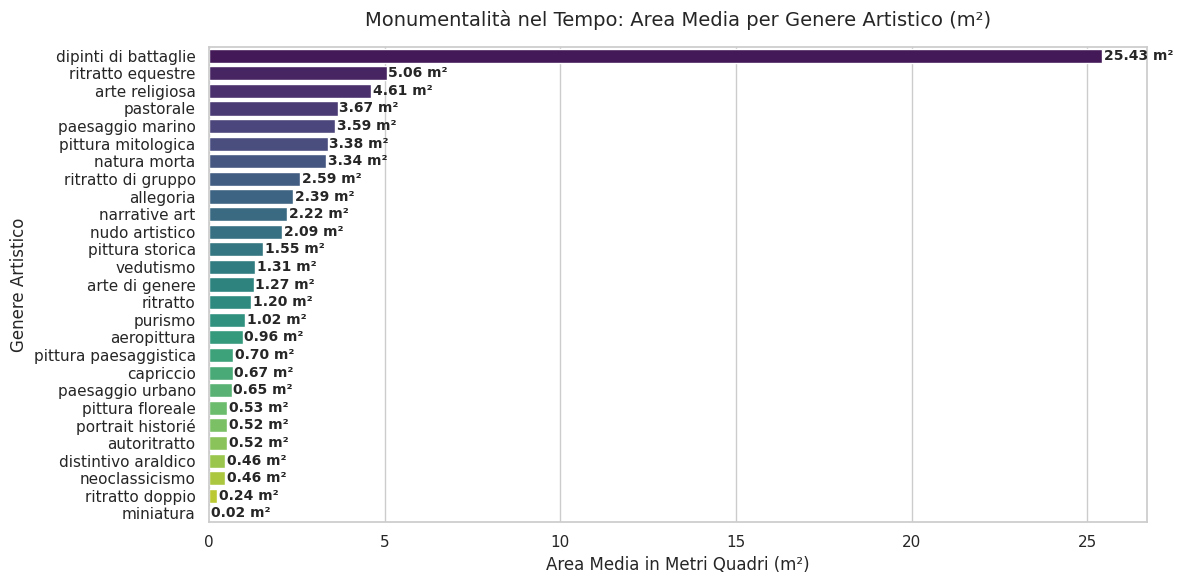

In [15]:
# Aggregazione Statistica per Genere e calcoli su area_m2
analisi_dimensioni = df_generi_split.groupby('genere_singolo')['area_m2'].agg(
    Numero_Opere='count',
    Area_Media_m2='mean',
    Area_Mediana_m2='median',
    Area_Massima_m2='max'
).reset_index()

# Ordina il database per Area_Media m2 in ordine decrescente
analisi_dimensioni = analisi_dimensioni.sort_values(by='Area_Media_m2', ascending=False)

# Mostra a video database
print('DATABASE PER GENERI')
display(analisi_dimensioni.round(3))

print("\n" + "="*80 + "\n")

# Generazione del Grafico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

grafico = sns.barplot(
    x='Area_Media_m2',
    y='genere_singolo',
    data=analisi_dimensioni,
    palette='viridis',
    hue='genere_singolo',
    legend=False
)

plt.title("Monumentalità nel Tempo: Area Media per Genere Artistico (m²)", fontsize=14, pad=15)
plt.xlabel("Area Media in Metri Quadri (m²)", fontsize=12)
plt.ylabel("Genere Artistico", fontsize=12)

for index, value in enumerate(analisi_dimensioni['Area_Media_m2']):
    plt.text(value + 0.05, index, f"{value:.2f} m²", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

##Sistemazione analisi introducendo media Bayesiana
Analizzando il database ordinato per area media mi sono accorta che alcuni generi avevano pochi elementi per stabilire una vera classifica sulla base dell'area media.
Volevo una classifica che tenesse conto anche del volume di opere presenti in un genere, per essere sicura che quell'area media rappresentasse veramente lo standard di superficie di un preciso genere.
Partendo da questo presupposto ho deciso di applicare la media Bayesiana, una media che tiene conto anche del volume di dati, e di ordinare il database secondo questa media.
La media Bayesiana si calcola in questo modo:
$$Area_{\text{Bayesiana}} = \frac{(v \times R) + (m \times C)}{v + m}$$
Dove:
- $v$ (Volume): È il numero di opere reali che hai per quel singolo genere nel database (la colonna Numero_Opere).
- $R$ (Rating/Raw Average): È la media grezza di quel genere, calcolata nel modo classico (somma delle aree diviso il numero di opere).
- $C$ (Collettività/Centralità): È la media globale di tutte le opere presenti nel tuo database, a prescindere dal genere. Rappresenta la nostra "certezza di partenza".
- $m$ (Massa di controllo/Soglia): È una costante che si sceglie. Rappresenta il numero di quadri virtuali "standard" che decidiamo di regalare a ogni categoria per stabilizzarla. Più si alza questo numero, più il freno diventa potente.

### Scenario di esempio: genere con pochissime opere
$$Area = \frac{(3 \times 5.06) + (10 \times 2.0)}{3 + 10} = \frac{15.18 + 20.0}{13} = \frac{35.18}{13} = 2.70\text{ m}^2$$
Dove:
- $v = 3$ (volume di opere)
- $R = 5.06$ (media grezza)
- $C = 2.0\text{ m}^2$ (media di tutte le opere)
- $m = 10$ (soglia scelta)

### Scenario di esempio: genere con tante opere
$$Area = \frac{(496 \times 4.61) + (10 \times 2.0)}{496 + 10} = \frac{2286.56 + 20.0}{506} = \frac{2306.56}{506} = 4.55\text{ m}^2$$
Dove:
- $v = 496$ (volume di opere)
- $R = 4.61$ (media grezza)
- $C = 2.0\text{ m}^2$ (media di tutte le opere)
- $m = 10$ (soglia scelta)

Come si può vedere dai 2 esempi:
-  nel caso in cui ci siano poche opere partendo da una media grezza dell'area di 5,06 si passa ad media Bayesiana dell'area di 2,70.
- nel caso in cui ci siano tante opere partendo da una media grezza dell'area di 4,61 si passa ad media Bayesiana dell'area di 4,55.

il pensiero bayesiano si rifaceva a questo principio:  
***"Aggiorna le tue convinzioni iniziali solo quando hai prove nuove e sufficientemente forti."***

Nel mio caso:
- La convinzione iniziale: In mancanza di dati solidi, un quadro di un genere qualsiasi si suppone sia grande quanto la media di tutti i quadri del database ($C$).
- La prova nuova : I quadri reali che trovi nel file CSV ($v$ ed $R$).

Se la prova nuova è debole (poche opere), rimaniamo vicini alla convinzione iniziale. Se la prova nuova è massiccia (centinaia di opere), abbandoniamo la convinzione iniziale e ci fidiamo cecamente della nuova scoperta.


## Introduzione nel codice della media Bayesiana

Media globale del database (C): 2.925 m²
--- CLASSIFICA CON MEDIA PONDERATA (BAYESIANA) ---


,genere_singolo,Numero_Opere,Area_Media_Grezza_m2,Area_Ponderata_m2
6,dipinti di battaglie,1,25.433,4.971
3,arte religiosa,496,4.613,4.580
25,ritratto equestre,3,5.060,3.418
17,pittura mitologica,67,3.381,3.322
13,paesaggio marino,3,3.589,3.078
10,natura morta,4,3.344,3.045
15,pastorale,1,3.667,2.992
23,ritratto di gruppo,2,2.588,2.869
9,narrative art,1,2.225,2.861
21,purismo,1,1.024,2.752


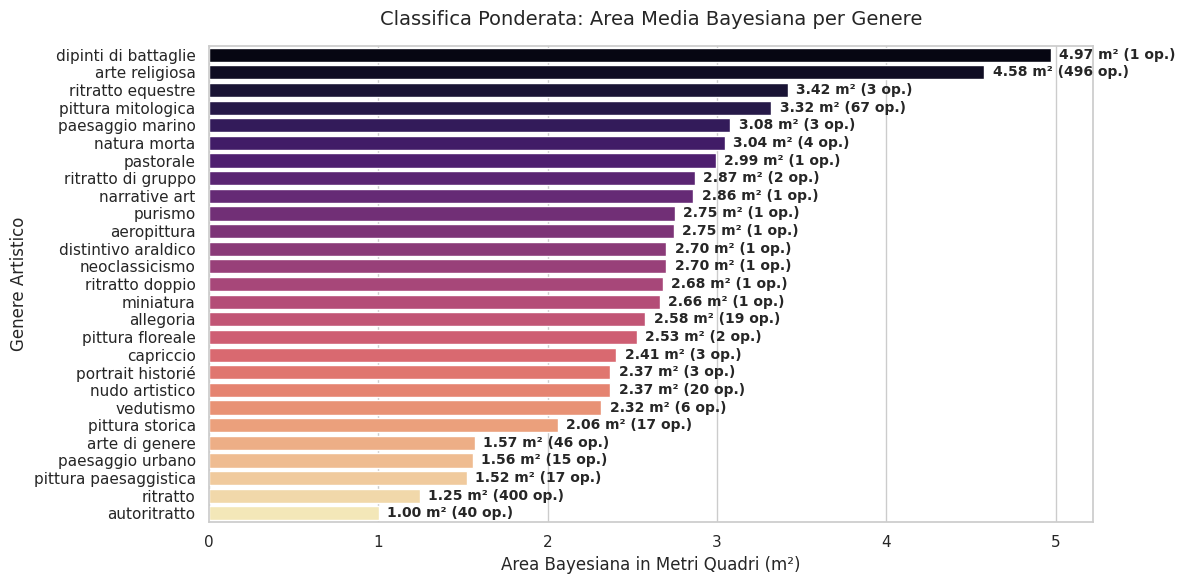

In [16]:
# Calcoliamo i parametri globali del database
C = df_dimensioni['area_m2'].mean()  # Area media globale di TUTTE le opere del dataset
m = 10                                # Soglia di stabilità

# Raggruppiamo i dati per genere (usando il df già pulito nei passaggi precedenti)
analisi_bayesiana = df_generi_split.groupby('genere_singolo')['area_m2'].agg(
    Numero_Opere='count',
    Area_Media_Grezza_m2='mean'
).reset_index()

# APPLICAZIONE DELLA MEDIA PONDERATA BAYESIANA
# Questa formula implementa il peso del volume delle opere direttamente sulla superficie
analisi_bayesiana['Area_Ponderata_m2'] = (
    (analisi_bayesiana['Numero_Opere'] * analisi_bayesiana['Area_Media_Grezza_m2']) + (m * C)
) / (analisi_bayesiana['Numero_Opere'] + m)

# Ordiniamo la classifica in base alla nuova area ponderata
analisi_bayesiana = analisi_bayesiana.sort_values(by='Area_Ponderata_m2', ascending=False)

print(f"Media globale del database (C): {C:.3f} m²")
print("--- CLASSIFICA CON MEDIA PONDERATA (BAYESIANA) ---")
display(analisi_bayesiana.round(3))

print("\n" + "="*80 + "\n")

# 4. Grafico a Barre della Media Ponderata Realistica
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

grafico = sns.barplot(
    x='Area_Ponderata_m2',
    y='genere_singolo',
    data=analisi_bayesiana,
    palette='magma',
    hue='genere_singolo',
    legend=False
)

plt.title("Classifica Ponderata: Area Media Bayesiana per Genere", fontsize=14, pad=15)
plt.xlabel("Area Bayesiana in Metri Quadri (m²)", fontsize=12)
plt.ylabel("Genere Artistico", fontsize=12)

# Aggiungiamo i dati stampati a lato di ogni barra
for index, row in enumerate(analisi_bayesiana.itertuples()):
    testo_etichetta = f"{row.Area_Ponderata_m2:.2f} m² ({row.Numero_Opere} op.)"
    plt.text(row.Area_Ponderata_m2 + 0.05, index, testo_etichetta, va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusioni
Ora il grafico ci rapprensenta una diversa classifica dei generi. Facciamo 2 esempi:
-  l'arte religiosa, che prima era al terzo posto, saltare in seconda posizione forte delle sue 496 opere a sostegno della posizione in classifica.
- l' arte pastorale, che prima era al quarto posto, salta in settima posizione avendo solo 1 opere per avvalorare la sua posizione in classifica.

NB. la categoria dipinti di battaglie è rimasta comunque al primo posto, nonostante ci sia solo un'opera nella categoria perché l'opera presente vanta una superficie di 25,43 m2, dato che mi può far desumere che il genere vanta opere di grandi dimensioni e quindi a mio avviso possa rimanere al primo posto.

Aumentanto la costante di soglia $m$ (spostandola da 10) si può vedere che la categorie dipinti di battaglia perde posizioni in classifica.



# 3.3 Quale tipologia di opere è più presente nella località di Bologna?

## Analisi preliminare sui luoghi
1. verifico il totale di righe del database
2. verifico quanti di questi luoghi compaiono almeno una volta
3. individuo il numero di righe che hanno il campo `luoghi` vuoto
4. mostro a video i tre punti precedenti
5. mostro a video la colonna `luoghi` del database `df` con a fianco il conteggio di quante volte appare tramite `.value_counts`

In [17]:
# Conteggio numerico dei luoghi
totale_righe = len(df)
luoghi_unici = df['luoghi'].nunique()
valori_mancanti = df['luoghi'].isna().sum()

print("--- STATISTICHE DELLA COLONNA 'luoghi' ---")
print(f"• Numero totale di righe nel database: {totale_righe}")
print(f"• Numero di LUOGHI UNICI (valori distinti): {luoghi_unici}")
print(f"• Righe senza alcun luogo specificato (vuote): {valori_mancanti}")
print("\n" + "="*50 + "\n")

# Elenco di tutti i luoghi presenti con la frequenza
print("--- ELENCO DEI LUOGHI ORDINATI PER FREQUENZA ---")
df['luoghi'].value_counts()

--- STATISTICHE DELLA COLONNA 'luoghi' ---
• Numero totale di righe nel database: 2444
• Numero di LUOGHI UNICI (valori distinti): 649
• Righe senza alcun luogo specificato (vuote): 82


--- ELENCO DEI LUOGHI ORDINATI PER FREQUENZA ---


,count
luoghi,
Palazzo degli Uffizi,118
Pinacoteca Nazionale di Bologna,56
Galleria all'aperto dell'affresco di Arcumeggia,45
Gallerie dell'Accademia,36
Gallerie d'Italia – Milano,36
...,...
Museo di arte sacra di San Donnino,1
Museo diocesano; oratorio di San Giovanni Battista,1
oratorio di San Sebastiano e della Vergine Assunta,1


## Formazione del database df_bologna
 1. conversione della colonna `luoghi` in formato stringa
 2. filtro le celle di `luoghi` che contengono 'bologna'
 3. applico la conversione e il filtro anche per la colonna `collezioni`
 4. creo il database `df.bologna` facendo una copia di `df`. Questo database è formato dalle righe che contengono 'bologna' in almeno uno dei campi `luoghi` o `collezioni`
 5. stampo a video il numero totale di opere trovate e l'elenco delle prime 10 opere con la funzione `.head(10)`

In [18]:
# Creiamo il filtro per la colonna 'luoghi'
# (astype(str) serve per evitare errori se ci sono celle vuote o numeri)
filtro_luoghi = df['luoghi'].astype(str).str.contains('bologna', case=False, na=False)

# Creiamo il filtro per la colonna 'collezioni'
filtro_collezioni = df['collezioni'].astype(str).str.contains('bologna', case=False, na=False)

# Uniamo i due filtri: teniamo la riga se "bologna" appare in luoghi OPPURE in collezioni
df_bologna = df[filtro_luoghi | filtro_collezioni].copy()

# Stampiamo i risultati per verificare quante opere abbiamo trovato
print("--- SCREENING DI BOLOGNA COMPLETATO ---")
print(f"\n • Numero di opere totali trovate: {len(df_bologna)}")
print("\n Anteprima delle prime 10 righe trovate:")

# Mostriamo le colonne chiave per controllare se l'estrazione è corretta
display(df_bologna[['titolo', 'artisti_clean', 'luoghi', 'collezioni']].head(10))

--- SCREENING DI BOLOGNA COMPLETATO ---

 • Numero di opere totali trovate: 61

 Anteprima delle prime 10 righe trovate:


,titolo,artisti_clean,luoghi,collezioni
82,Strage degli innocenti,guido reni (maschio),Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna
339,Cristo incoronato di spine,annibale carracci (maschio); ludovico carracci...,Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna
384,Visitazione,jacopo tintoretto (maschio),Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna
405,Ritratto di neonata nella culla,lavinia fontana (femmina),Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna
424,Susanna e i vecchioni,onofrio palumbo (maschio); artemisia gentilesc...,Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna
475,Sant'Ambrogio,giusto de' menabuoi (maschio),Pinacoteca Nazionale di Bologna,collezione Francesco Arcangeli
523,Sepoltura di cristo,prospero fontana (maschio),Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna
579,Ritratto di Pio VIII,clemente alberi (maschio),Palazzo d'Accursio,Collezioni comunali d'arte di Bologna
721,Ritratto di papa Clemente XIII Rezzonico,anton raphael mengs (maschio),Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna
764,Autoritratto,giuseppe maria crespi (maschio),Pinacoteca Nazionale di Bologna,Pinacoteca Nazionale di Bologna


## Analisi sul database df_bologna
1. per avere un calcolo percentuale calcolo il totale delle opere presenti in `df_bologna` tramite `len(df_bologna)`
2. verifico se `genere_singolo` è una colonna presente all'interno di `df_bologna`
  - se non è presente attraverso `.split(';')` e `.explode` esplodo i generi
3. crea il database analisi_generi prendendo le colonne Genere Artistico e Numero_Opere e aggiungo la colonna Percentuale
4. mostro a schermo analisi_generi con i numeri arrotondati alla seconda cifra decimale
5. crea il database analisi_artisti prendendo le colonne Artista e Numero_Opere e aggiungo la colonna Percentuale
6. mostro a schermo analisi_artisti con i numeri arrotondati alla seconda cifra decimale

In [19]:
# Calcoliamo il totale delle opere bolognesi per fare le percentuali
totale_bo = len(df_bologna)

print(f"Totale opere associate a Bologna analizzate: {totale_bo}\n")

print("="*80 + "\n")

#ANALISI SUI GENERI PREVALENTI A BOLOGNA
print("DISTRIBUZIONE DEI GENERI ARTISTICI")

# Controlliamo se 'genere_singolo' è già presente, altrimenti esplodiamo la colonna 'genere' al volo
if 'genere_singolo' in df_bologna.columns:
    analisi_generi = df_bologna['genere_singolo'].value_counts().reset_index()
else:
    # Se partiamo dalla colonna 'genere' con i separatori ';', la esplodiamo qui direttamente
    analisi_generi = df_bologna['generi_clean'].astype(str).str.split(';').explode().str.strip().value_counts().reset_index()

analisi_generi.columns = ['Genere Artistico', 'Numero_Opere']
analisi_generi['Percentuale %'] = (analisi_generi['Numero_Opere'] / totale_bo) * 100

display(analisi_generi.round(2))

#ANALISI ARTISTI PREVALENTI A BOLOGNA
print("TOP ARTISTI PRESENTI NEL DATASET DI BOLOGNA")

# Raggruppiamo per la colonna artisti_clean
analisi_artisti = df_bologna['artisti_clean'].value_counts().reset_index()
analisi_artisti.columns = ['Artista', 'Numero_Opere']
analisi_artisti['Percentuale %'] = (analisi_artisti['Numero_Opere'] / totale_bo) * 100

# Mostriamo i primi 15 artisti più presenti
display(analisi_artisti.head(15).round(2))

Totale opere associate a Bologna analizzate: 61


DISTRIBUZIONE DEI GENERI ARTISTICI


,Genere Artistico,Numero_Opere,Percentuale %
0,arte religiosa,28,45.90
1,nan,25,40.98
2,ritratto,6,9.84
3,autoritratto,1,1.64
4,pittura mitologica,1,1.64


TOP ARTISTI PRESENTI NEL DATASET DI BOLOGNA


,Artista,Numero_Opere,Percentuale %
0,guido reni (maschio),5,8.20
1,ludovico carracci (maschio),5,8.20
2,annibale carracci (maschio),5,8.20
3,guercino (maschio),5,8.20
4,prospero fontana (maschio),2,3.28
5,simone dei crocifissi (maschio),2,3.28
6,francesco albani (maschio),2,3.28
7,domenichino (maschio),2,3.28
8,giovanni antonio burrini (maschio),2,3.28
9,giuseppe maria crespi (maschio),2,3.28


## Creo i grafici per visualizzare i generi e gli artisti


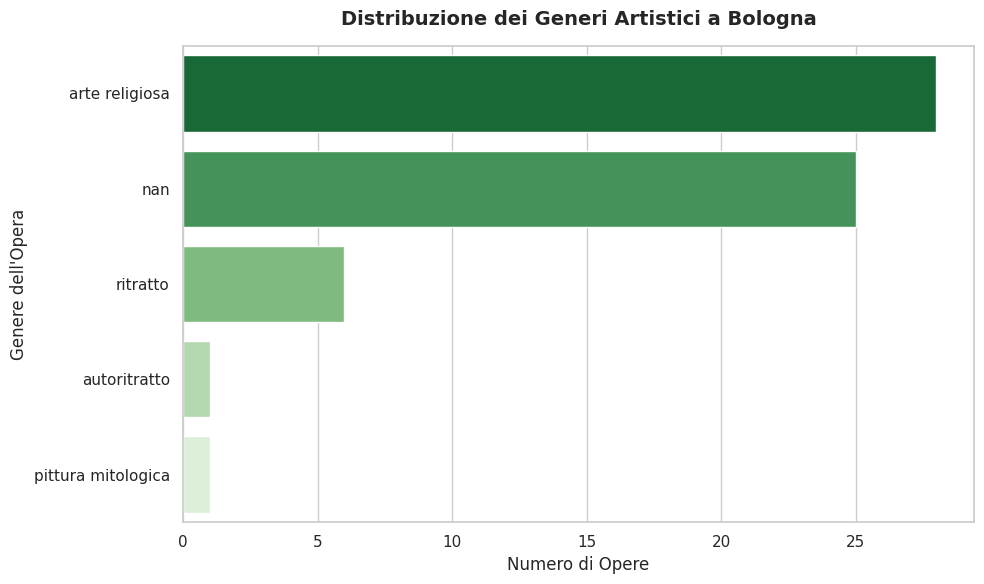

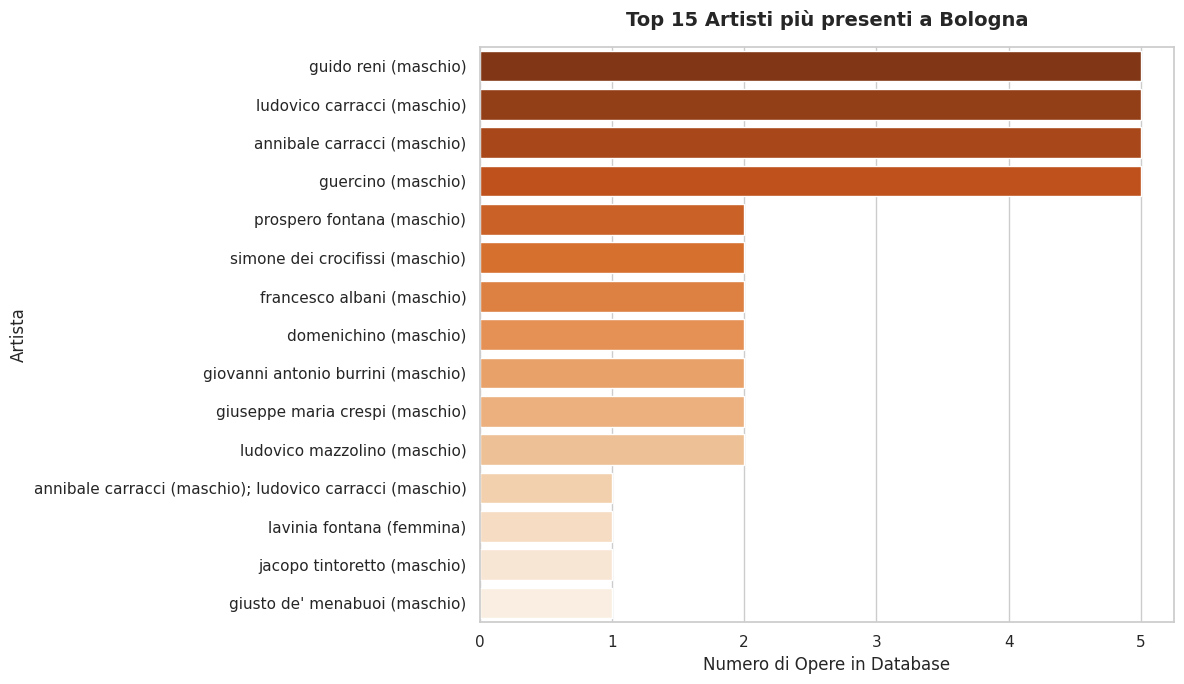

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo uno stile grafico pulito ed elegante per tutti i grafici
sns.set_theme(style="whitegrid")
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


if 'genere_singolo' in df_bologna.columns:
    dati_generi = df_bologna['genere_singolo'].value_counts()
else:
    # Se la colonna si chiama 'genere' ed ha i punti e virgola, la esplodiamo al volo
    dati_generi = df_bologna['generi_clean'].astype(str).str.split(';').explode().str.strip().value_counts()



# GRAFICO 1: I GENERI ARTISTICI (Barre Orizzontali)
plt.figure(figsize=(10, 6))

# Creiamo il grafico a barre orizzontali
sns.barplot(x=dati_generi.values, y=dati_generi.index, hue=dati_generi.index, palette="Greens_r", legend=False)

plt.title('Distribuzione dei Generi Artistici a Bologna', pad=15, weight='bold')
plt.xlabel('Numero di Opere')  # Sistemato: sui numeri c'è il conteggio
plt.ylabel('Genere dell\'Opera') # Sistemato: sui testi ci sono i generi
plt.tight_layout()
plt.show()

print("\n" + "="*80 + "\n")


# GRAFICO 2: GLI ARTISTI PIÙ PRESENTI (Barre Orizzontali)
plt.figure(figsize=(12, 7))

# Prendiamo i primi 15 artisti più presenti nel dataset bolognese
top_artisti = df_bologna['artisti_clean'].value_counts().head(15)

# Creiamo il grafico a barre orizzontali
sns.barplot(x=top_artisti.values, y=top_artisti.index, hue=top_artisti.index, palette="Oranges_r", legend=False)

plt.title('Top 15 Artisti più presenti a Bologna', pad=15, weight='bold')
plt.xlabel('Numero di Opere in Database')
plt.ylabel('Artista')
plt.tight_layout()
plt.show()